# Importing Libraries and Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

import pymc as pm
import arviz as az

In [2]:
folder_path = '/content/drive/MyDrive/Work/Personal Projects/RentalPropertyOptimizer/Data' #Add folder path here

In [3]:
# Importing Cleaned Enriched AirBnB listings data

spreadsheets = [file for file in os.listdir(f"{folder_path}/AirBnB Listings/Cleaned Enriched Listings") if file.endswith('.csv')]
cities = []

for spreadsheet in spreadsheets:
  if '_bookings_and_prices.csv' in spreadsheet:
    city_state = spreadsheet.replace('_bookings_and_prices.csv', '')
    city = '_'.join(city_state.split('_')[:-1])
    cities.append(city)

    df_name = f'df_{city}'
    globals()[df_name] = pd.read_csv(f"{folder_path}/AirBnB Listings/Cleaned Enriched Listings/{spreadsheet}")

In [4]:
for city in cities:
  df = globals().get(f'df_{city}')
  print(f"{city}: {df.shape}")

fort_lauderdale: (35151, 45)
nashville: (41383, 45)
miami: (41323, 45)
jacksonville: (15107, 45)
phoenix: (5735, 45)
myrtle_beach: (10944, 45)
houston: (25783, 45)
tampa: (22281, 45)
charlotte: (17314, 45)
indianapolis: (10821, 45)
destin: (16192, 45)
dallas: (7511, 45)
san_antonio: (21474, 45)
austin: (24495, 45)
cape_coral: (18995, 45)
atlanta: (23820, 45)


# Exploratory Data Analysis

In [5]:
df_all_cities = pd.DataFrame()
expected_rows = 0

for city in cities:
  df_city = globals().get(f'df_{city}').copy()
  df_city['city'] = city
  expected_rows += df_city.shape[0]
  df_all_cities = pd.concat([df_all_cities, df_city], axis = 0)

df_all_cities.reset_index(drop = True, inplace = True)
df_all_cities_aggregate = df_all_cities.groupby(["city", 'ID'], as_index = False)['Avg_Price'].mean()

In [6]:
df_all_cities.head(2)

,ID,Year_Index,Avg. Occupany %,Month,Bookings,Avg_Price,Scrape,Latitude,Longitude,isSuperHost,...,Others,Theater,Pets,Gym- Private,Hot Tub/Pool- Shared,Ski,city_center_lat,city_center_lon,distance_from_city_center,city
0,1000169330006296322,0,83,January,4.0,103.0,False,26.09370,-80.18778,True,...,1,0,1,0,0,0,26.130248,-80.128023,7219.041515,fort_lauderdale
1,1000671888240230114,0,90,January,28.0,375.0,False,26.14537,-80.12438,True,...,0,0,1,0,0,0,26.130248,-80.128023,1720.383199,fort_lauderdale


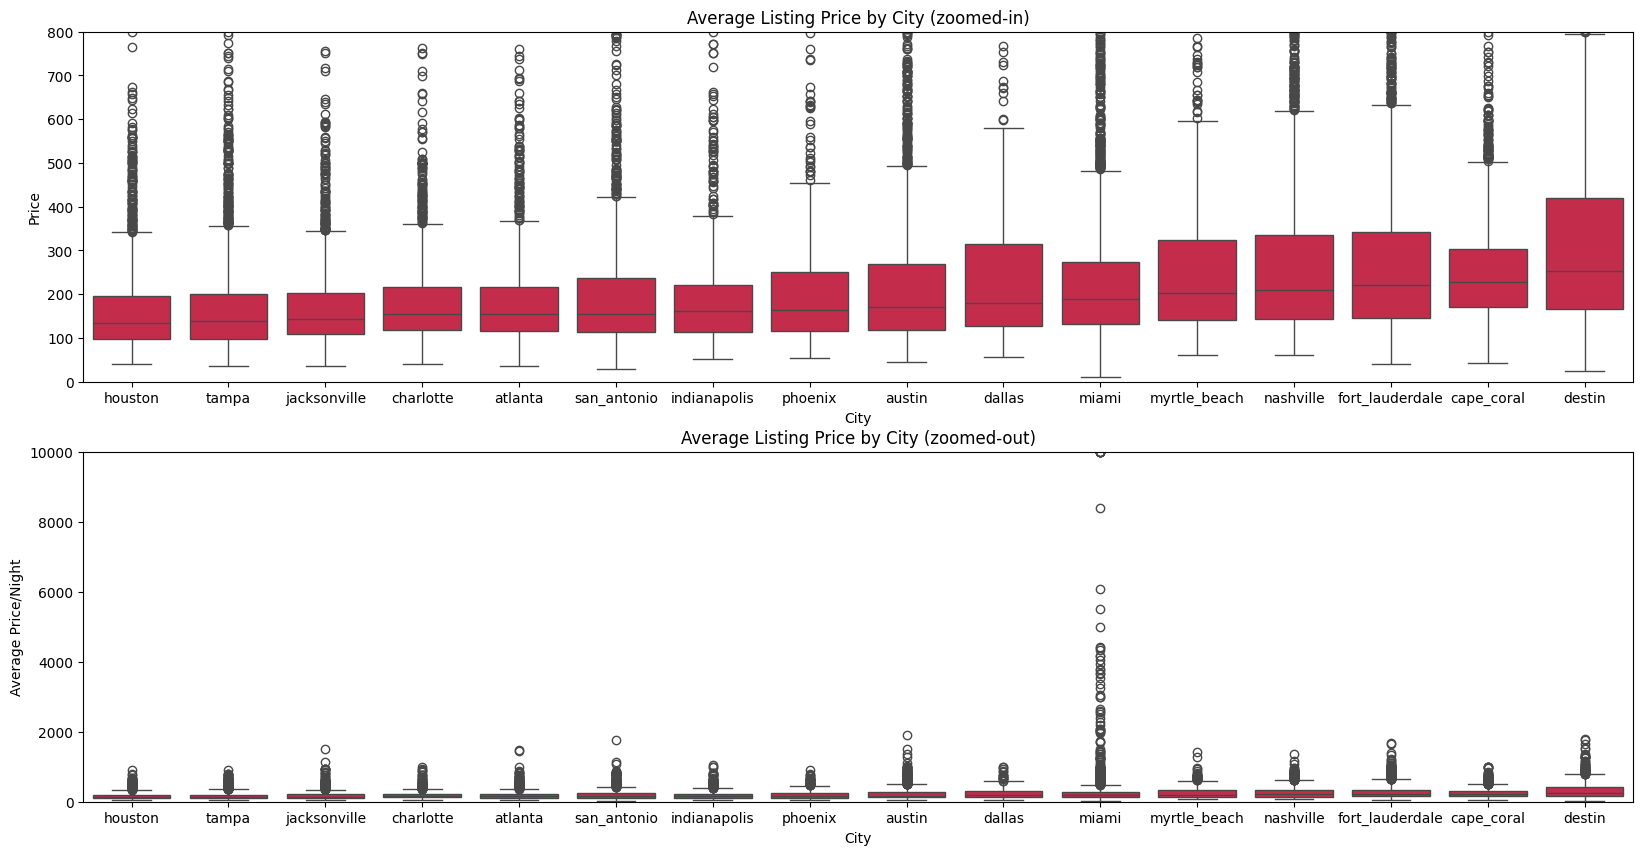

<Figure size 640x480 with 0 Axes>

In [9]:
fig, ax = plt.subplots(2, 1, figsize  = (20, 10))
city_order = df_all_cities_aggregate.groupby('city')['Avg_Price'].median().sort_values().index

sns.boxplot(data = df_all_cities_aggregate, x = 'city', y = 'Avg_Price', ax = ax[0], color = 'crimson', order = city_order)
ax[0].set_title('Average Listing Price by City (zoomed-in)')
ax[0].set_ylim(0, 800)
ax[0].set_ylabel('Price')
ax[0].set_xlabel('City')

sns.boxplot(data = df_all_cities_aggregate, x = 'city', y = 'Avg_Price', ax = ax[1], color = 'crimson', order = city_order)
ax[1].set_title('Average Listing Price by City (zoomed-out)')
ax[1].set_ylim(0, 10000)
ax[1].set_ylabel('Average Price/Night')
ax[1].set_xlabel('City')

plt.show()
plt.tight_layout()

**Key observations:**

*  Miami has the highest skew among all the cities.
*  The median listing price appears to be correlated with variance.
*  Listings in coastal cities typically have a higher median price.



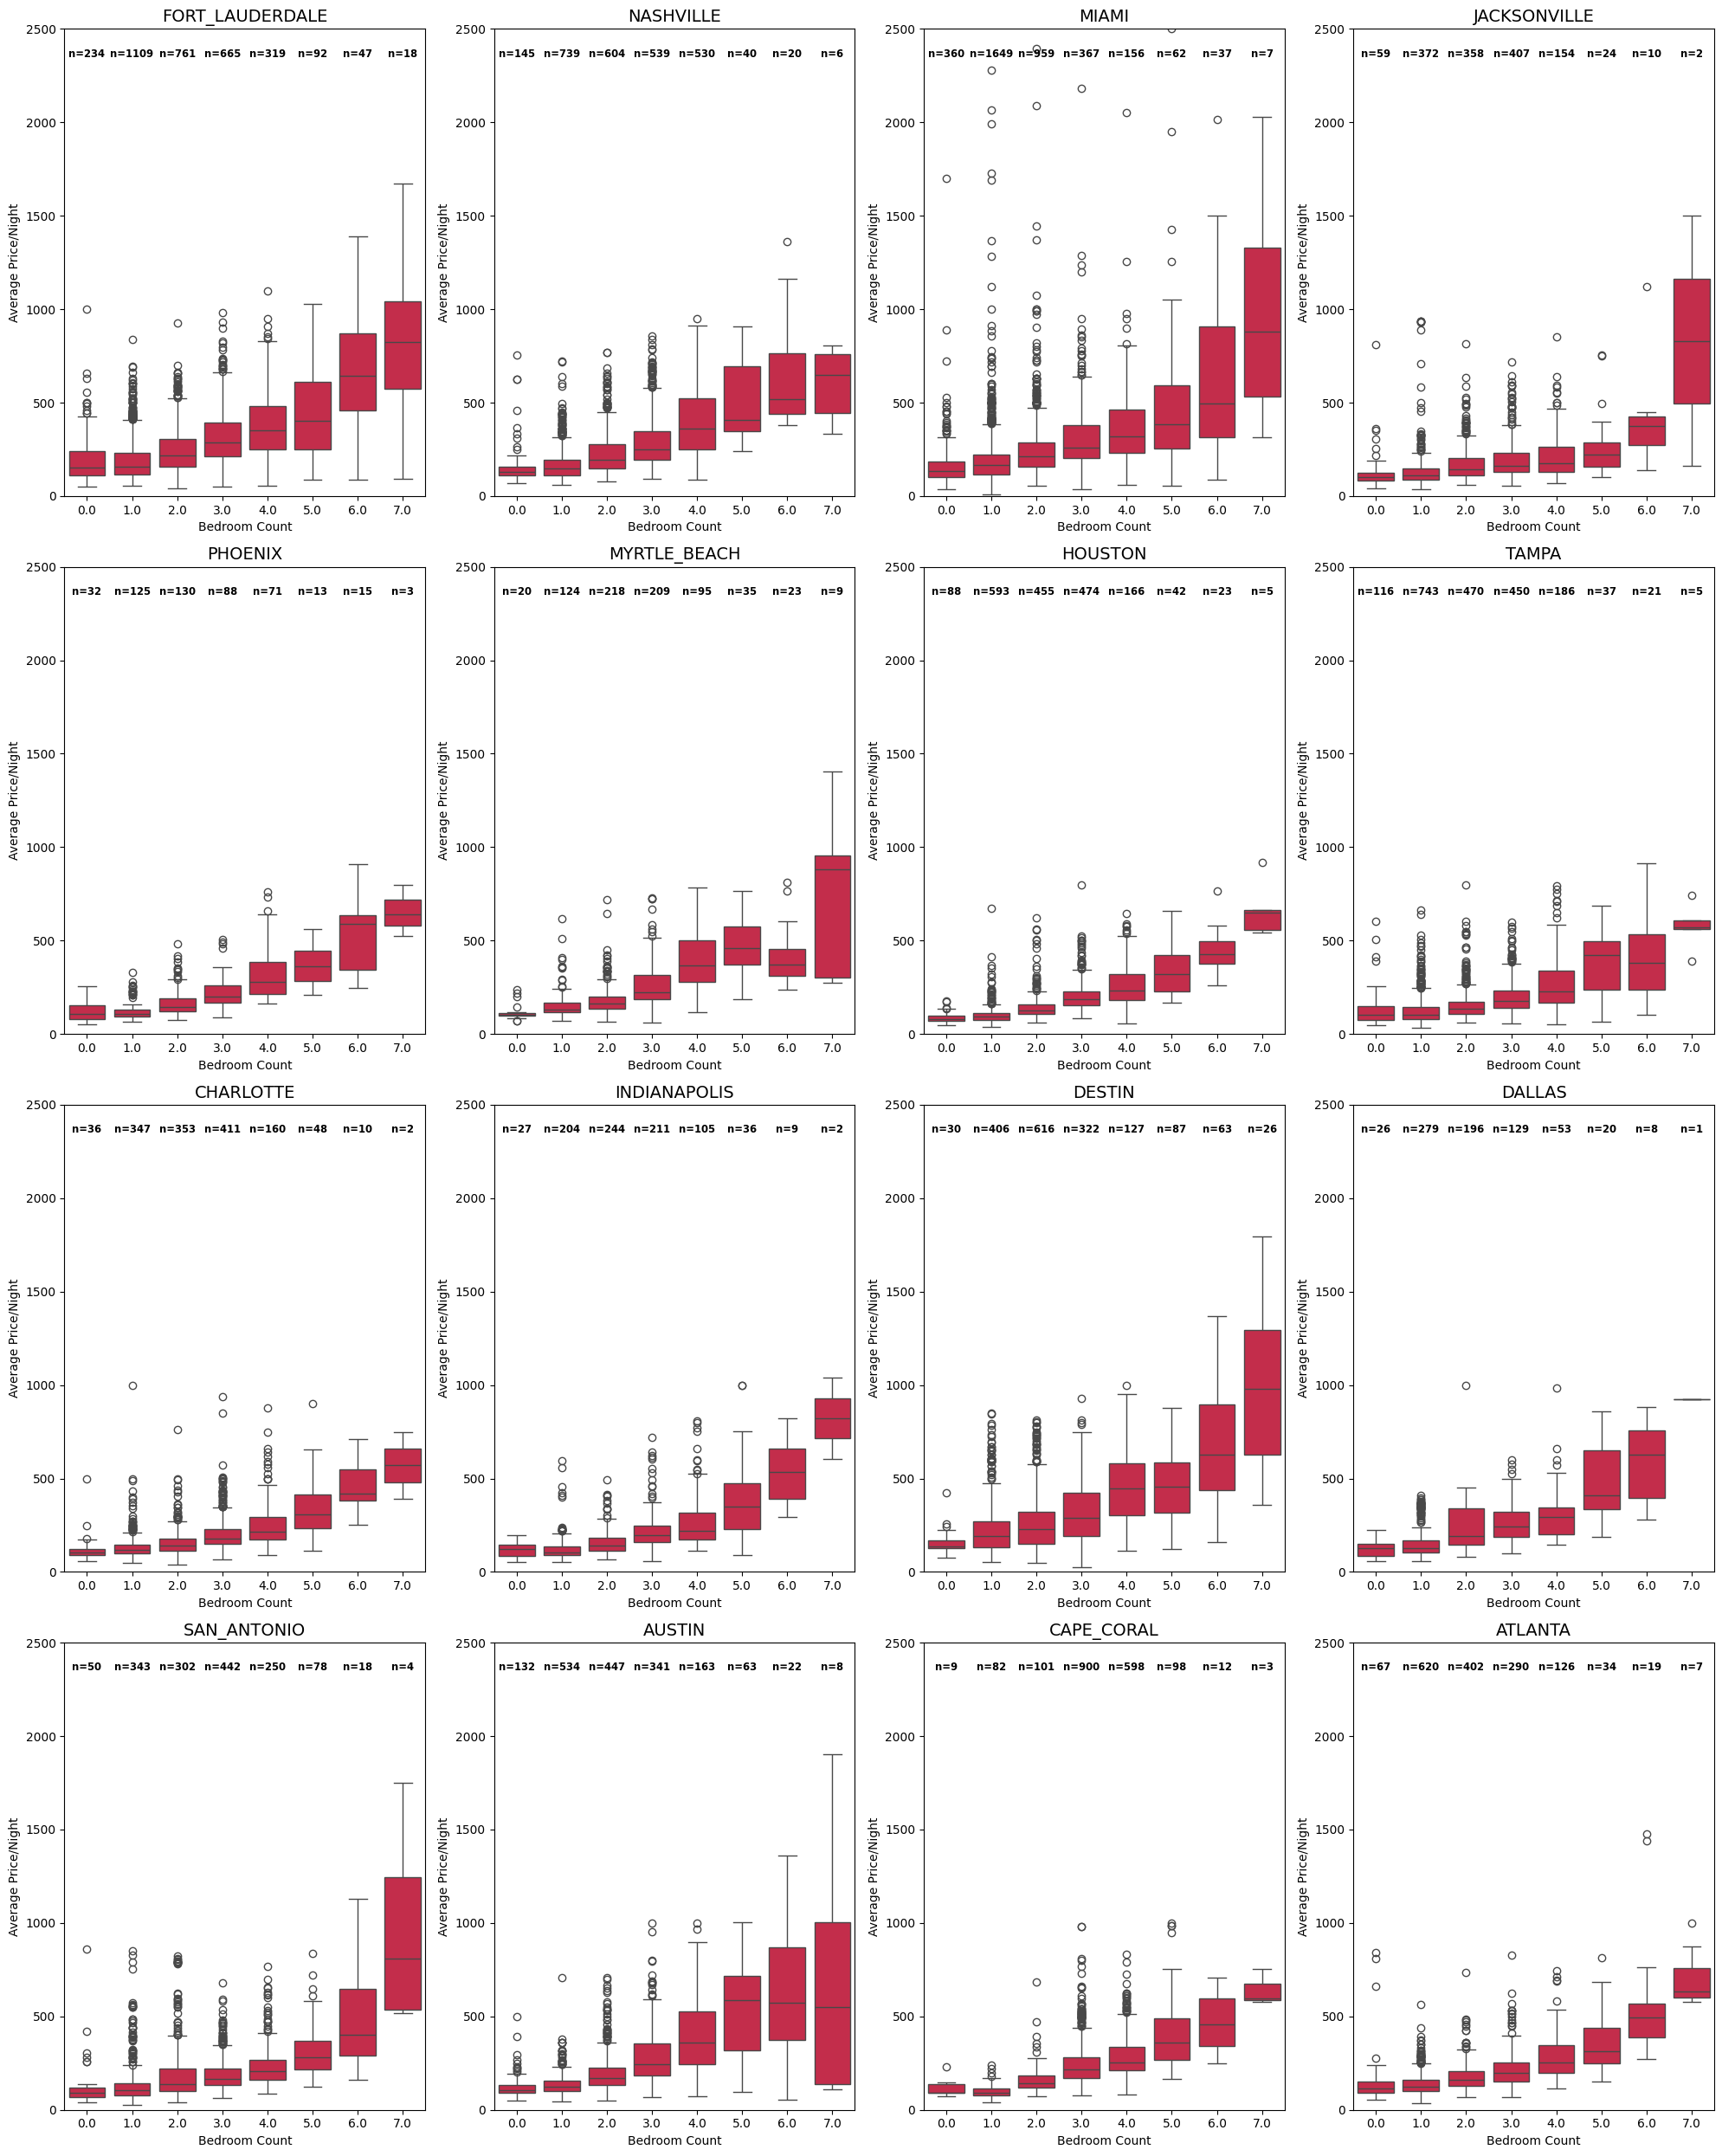

In [10]:
fig, ax = plt.subplots(4, 4, figsize=(20, 25)) # Increased height for better spacing

for i, city in enumerate(cities):
    curr_ax = ax[i // 4, i % 4]
    df = globals().get(f'df_{city}').copy()
    df = df.groupby(["ID", "Bedrooms"], as_index = False)['Avg_Price'].mean()

    # Generate the Boxplot
    sns.boxplot(data=df, y='Avg_Price', x='Bedrooms', ax=curr_ax, color='crimson')

    # Calculate Sample Sizes per Bedroom Category
    # We get the counts and align them with the x-axis tick positions
    counts = df.groupby('Bedrooms')['Avg_Price'].count().values

    # Add text labels over whiskers
    for xtick in range(len(counts)):
        # We place the text at the xtick position,
        # and at y = 2300 (just below your 2500 limit)
        curr_ax.text(xtick, 2350, f'n={counts[xtick]}', horizontalalignment='center', size='small', color='black', weight='semibold')

    # Formatting
    curr_ax.set_ylim(0, 2500)
    curr_ax.set_ylabel('Average Price/Night')
    curr_ax.set_xlabel('Bedroom Count')
    curr_ax.set_title(f'{city.upper()}', fontsize=14)

plt.tight_layout()
plt.show()

**Key observations:**

*   Bedroom count has a positive effect on price in all markets.
*   Three major types of effect can be observed- a step-wise effect (e.g., In Dallas, price suddenly goes up for properties with 2+ bedrooms), a constant effect (e.g., In Miami, price goes up uniformly for each additional bedroom), a flattening effect (e.g., in Austin, the marginal utility of an additional bedroom shrinks beyond 5 bedrooms).
*  In most markets, sample size goes below 30 for 6+ bedrooms.





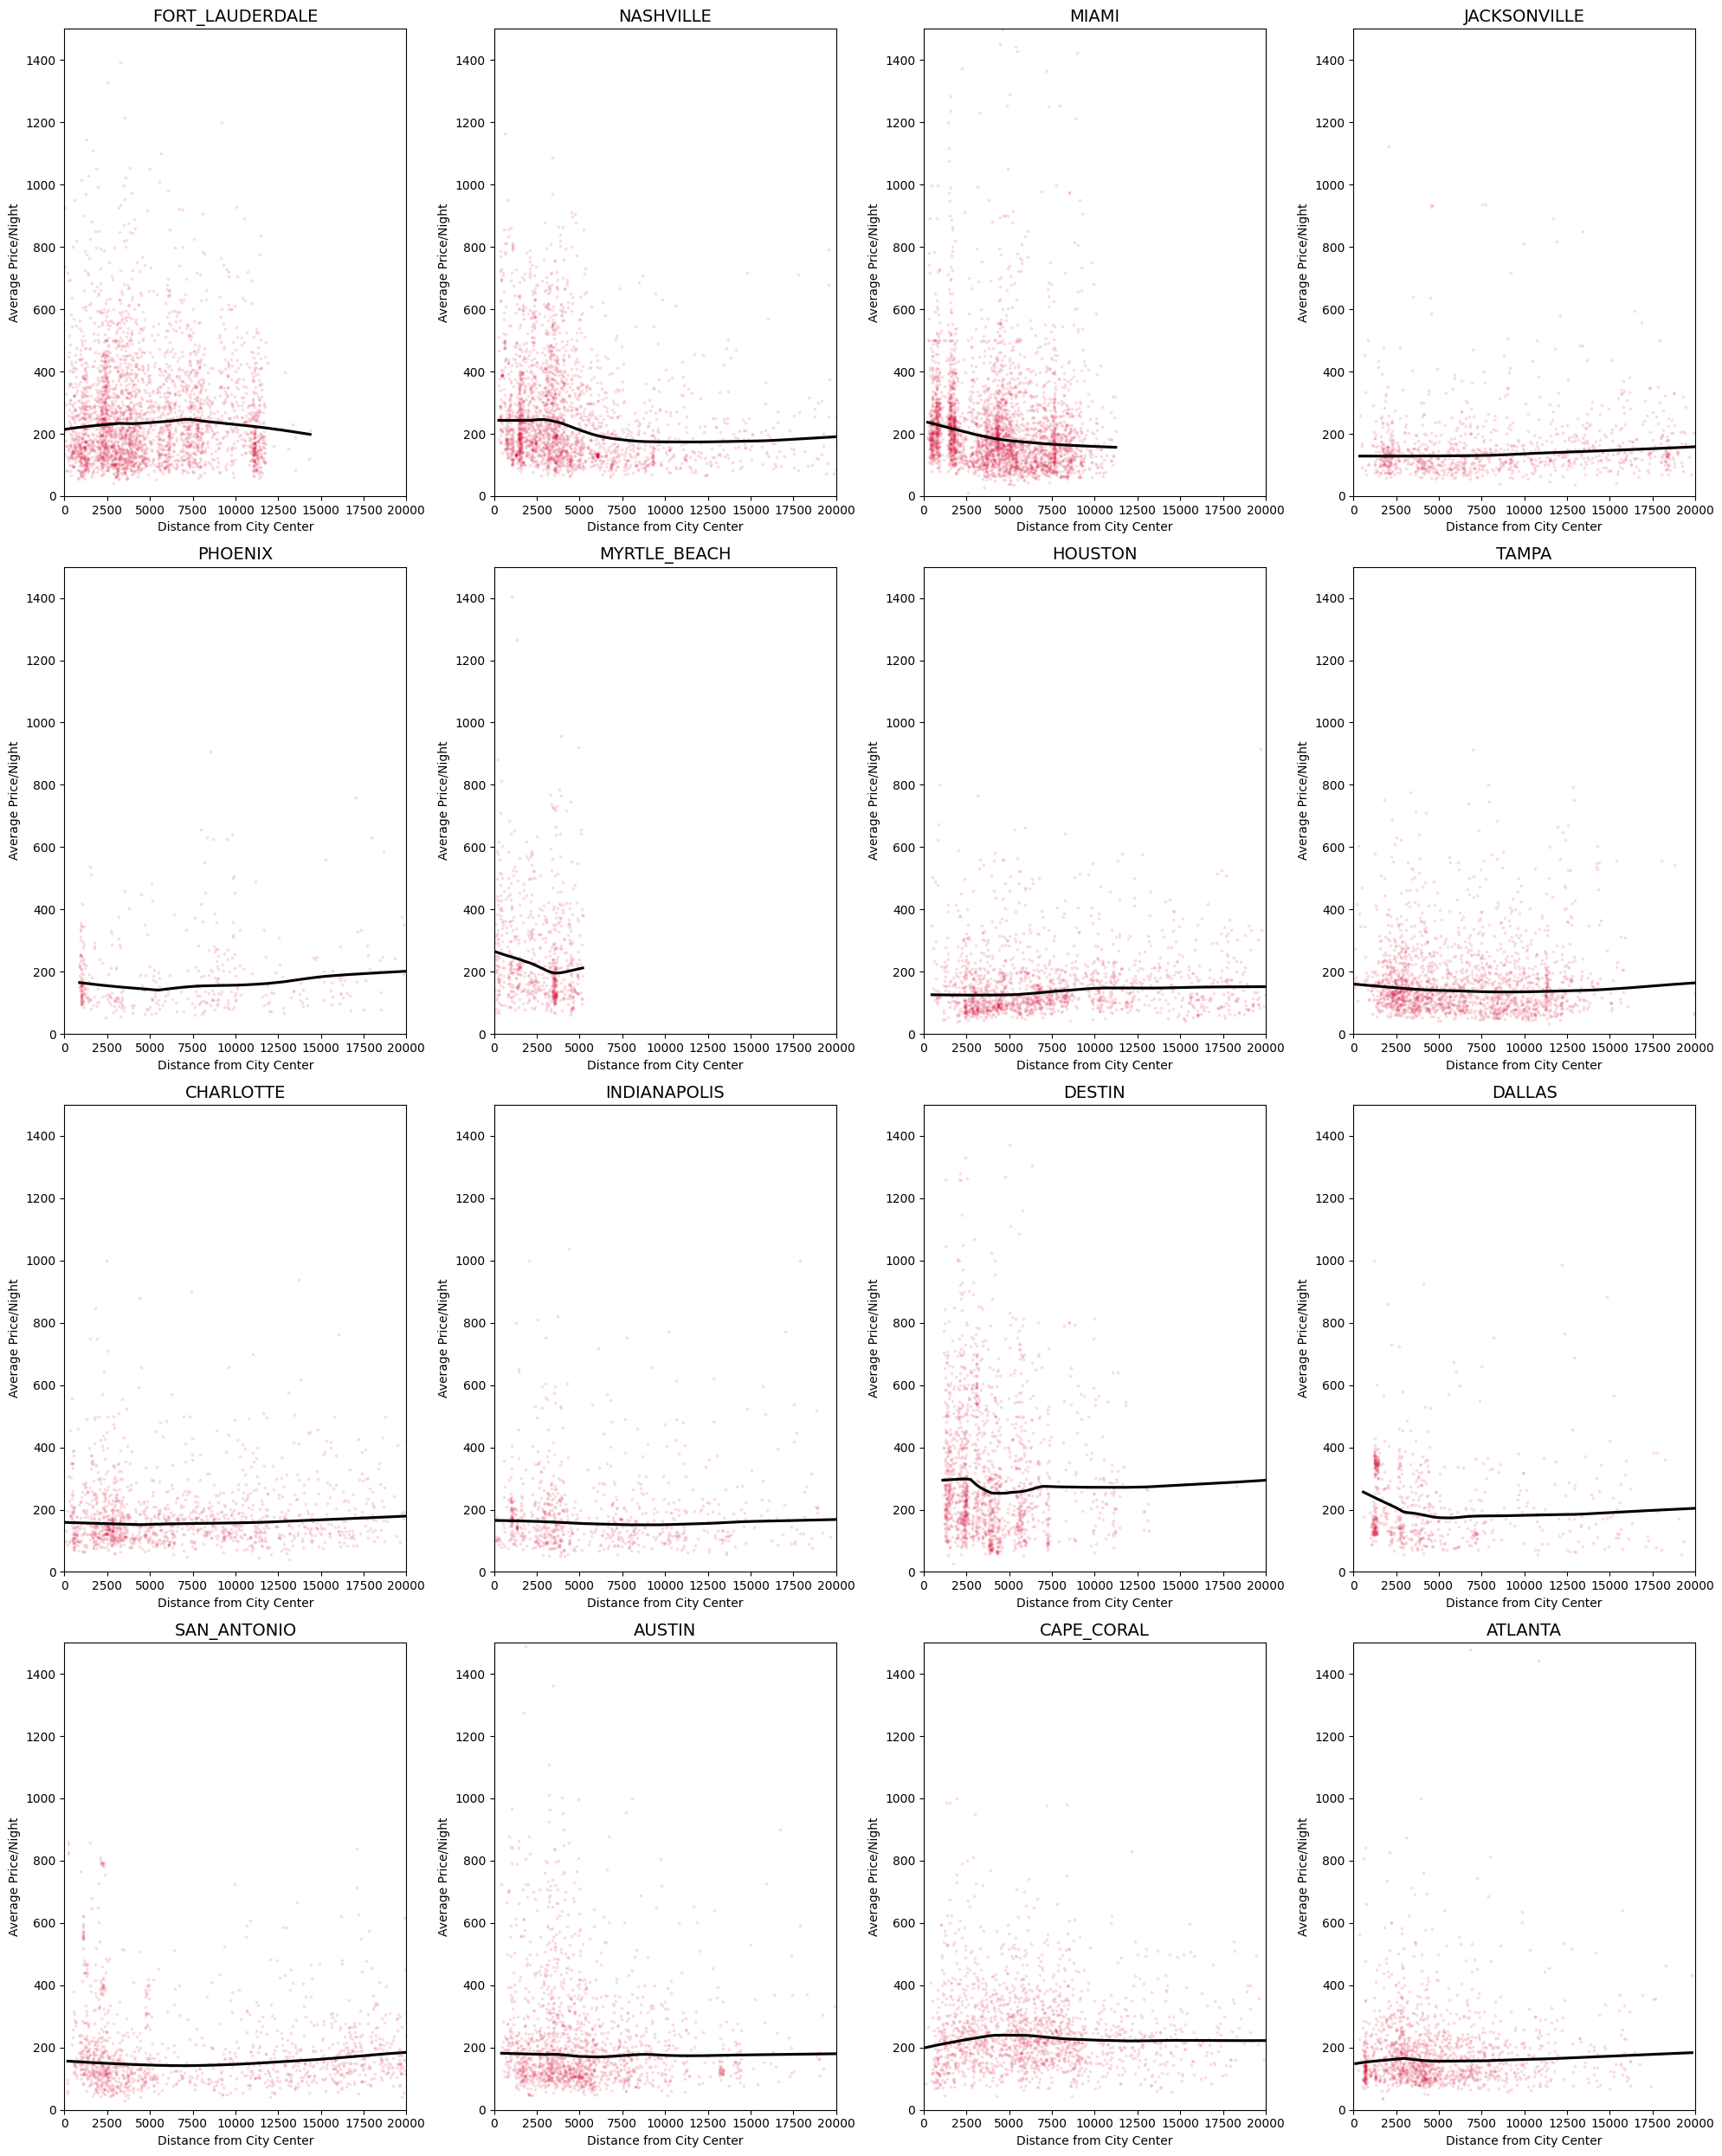

In [11]:
fig, ax = plt.subplots(4, 4, figsize=(20, 25))

for i, city in enumerate(cities):
    curr_ax = ax[i // 4, i % 4]
    df = globals().get(f'df_{city}').copy()
    df = df.groupby(["ID", "distance_from_city_center"], as_index = False)['Avg_Price'].mean()

    # Generate the Boxplot
    sns.regplot(data=df, y='Avg_Price', x='distance_from_city_center', ax=curr_ax, lowess=True, color='crimson', marker='o', scatter_kws={'alpha': 0.1, 's': 3}, line_kws={'color': 'black'}, x_jitter=0.2)

    # Formatting
    curr_ax.set_ylim(0, 1500)
    curr_ax.set_xlim(0, 20000)
    curr_ax.set_ylabel('Average Price/Night')
    curr_ax.set_xlabel('Distance from City Center')
    curr_ax.set_title(f'{city.upper()}', fontsize=14)

plt.tight_layout()
plt.show()

Key observations:

*   The effect of distance from city-center has a non-linear relationship with price. In some cities, price peaks at distances around 2,500 meters and then drops. In others, there is a linear relationship between price and distance.
*   In some markets the effect of distance is non-existent or negative.
*   2,500 meters (2.5 km) is a reasonable cutoff if this is used as a binary variable instead of a continuous variable.


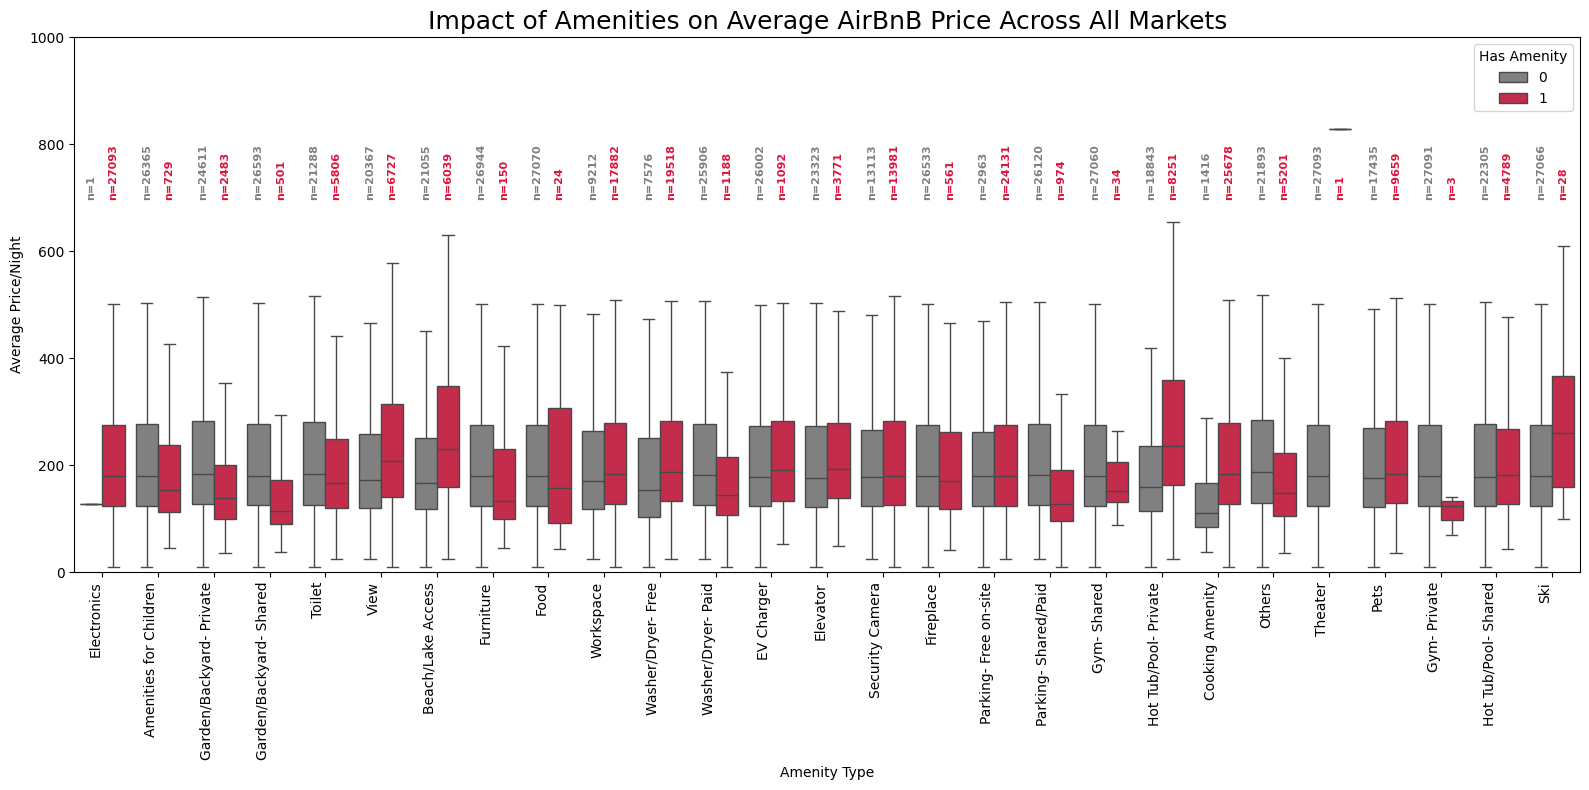

In [12]:
amenities = ['Electronics', 'Amenities for Children', 'Garden/Backyard- Private','Garden/Backyard- Shared', 'Toilet', 'View', 'Beach/Lake Access', 'Furniture', 'Food', 'Workspace', 'Washer/Dryer- Free', 'Washer/Dryer- Paid', 'EV Charger', 'Elevator', 'Security Camera', 'Fireplace', 'Parking- Free on-site', 'Parking- Shared/Paid', 'Gym- Shared', 'Hot Tub/Pool- Private', 'Cooking Amenity', 'Others', 'Theater', 'Pets', 'Gym- Private', 'Hot Tub/Pool- Shared', 'Ski']

df_long = df_all_cities.groupby(["ID"] + amenities, as_index=False)['Avg_Price'].mean()
df_long = df_long.melt(id_vars=['Avg_Price'], value_vars=amenities, var_name='Amenity', value_name='Has_Amenity').reset_index()

# Create the plot
plt.figure(figsize=(16, 8)) # Slightly larger for many labels
ax = sns.boxplot(data=df_long, x='Amenity', y='Avg_Price', hue='Has_Amenity', palette={True: 'crimson', False: 'gray'}, showfliers=False)

# Calculate and Add Sample Sizes
counts = df_long.groupby(['Amenity', 'Has_Amenity']).size().reset_index(name='count')

# Get the list of amenities in the order they appear on the X-axis
x_labels = [t.get_text() for t in ax.get_xticklabels()]

for i, amenity in enumerate(x_labels):
    # Get counts for False (gray) and True (crimson) for this specific amenity
    n_false = counts[(counts['Amenity'] == amenity) & (counts['Has_Amenity'] == False)]['count'].values
    n_true = counts[(counts['Amenity'] == amenity) & (counts['Has_Amenity'] == True)]['count'].values

    ax.text(i - 0.2, 700, f'n={n_false[0]}', ha='center', size=8, color='gray', weight='bold', rotation=90)
    ax.text(i + 0.2, 700, f'n={n_true[0]}', ha='center', size=8, color='crimson', weight='bold', rotation=90)

# Formatting
plt.title('Impact of Amenities on Average AirBnB Price Across All Markets', fontsize=18)
plt.ylim(0, 1000)
plt.ylabel('Average Price/Night')
plt.xlabel('Amenity Type')
plt.xticks(rotation=90, ha='right')
plt.legend(title='Has Amenity', loc='upper right')

plt.tight_layout()
plt.show()

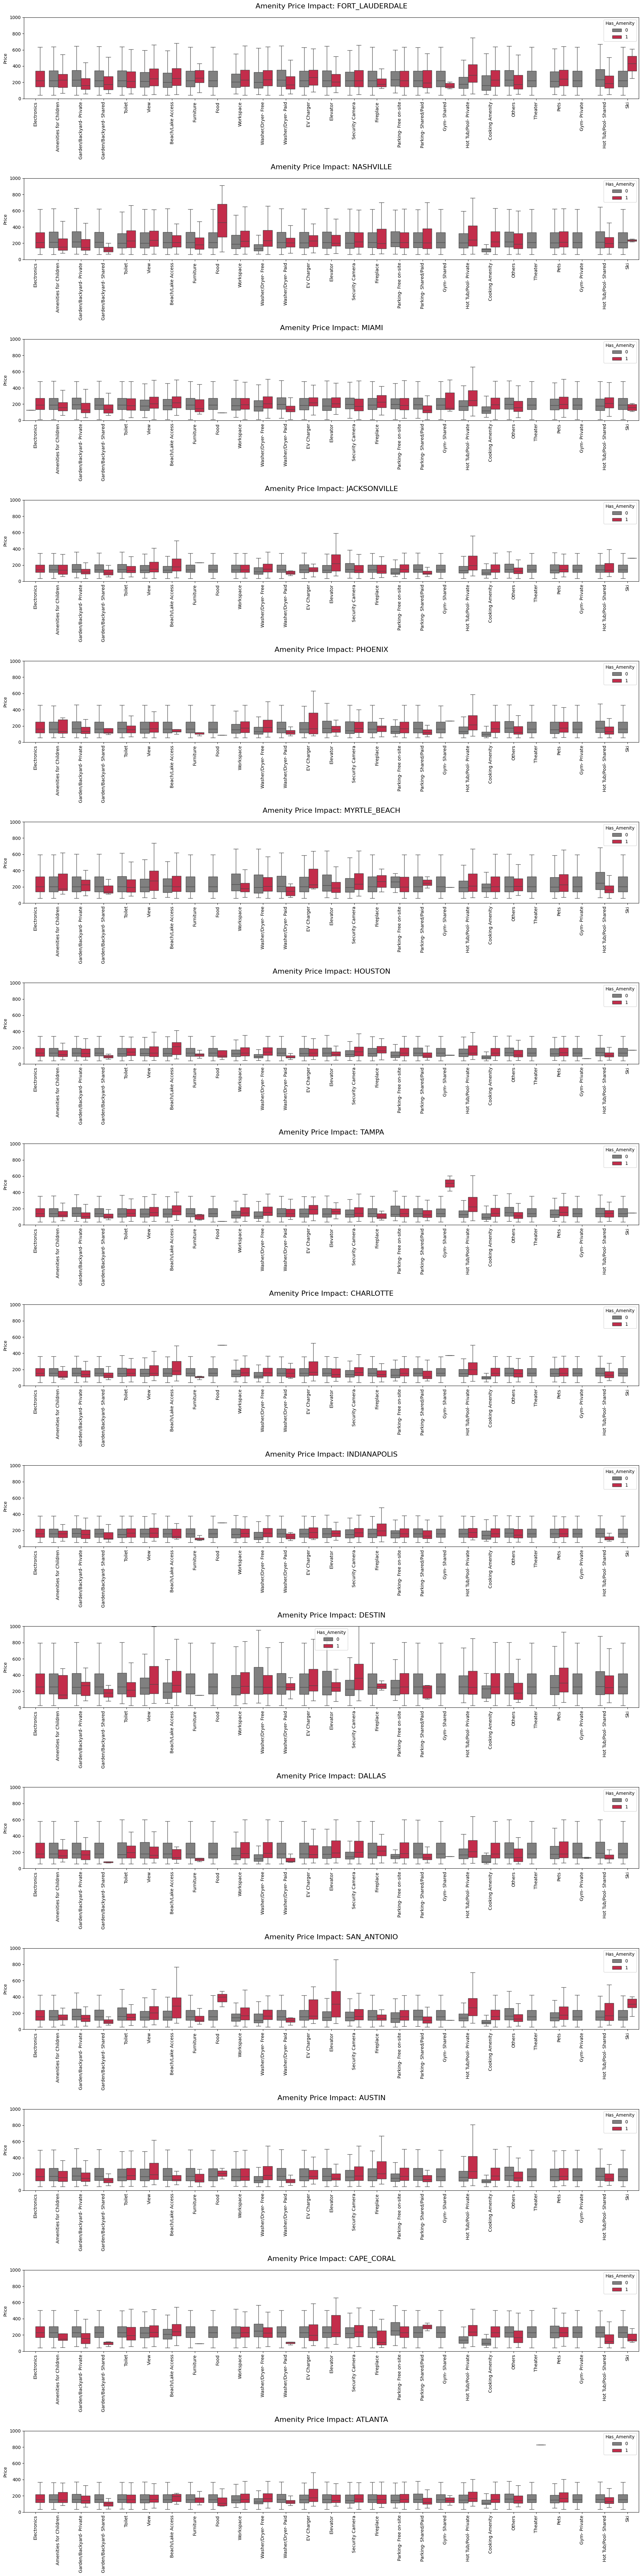

In [13]:
# 1. Prepare the long-form data grouped by City AND ID
# We keep 'city' in id_vars so we can filter the subplots later
df_long = df_all_cities.groupby(["ID", "city"] + amenities, as_index=False)['Avg_Price'].mean()
df_long = df_long.melt(id_vars=['city', 'Avg_Price'], value_vars = amenities, var_name='Amenity', value_name='Has_Amenity').reset_index()

# 2. Create 16 rows of subplots
fig, axes = plt.subplots(len(cities), 1, figsize=(20, 5 * len(cities)))

for i, city in enumerate(cities):
    curr_ax = axes[i]
    city_data = df_long[df_long['city'] == city]

    # Generate Boxplot for this specific city
    sns.boxplot(data=city_data, x='Amenity', y='Avg_Price', hue='Has_Amenity', palette={True: 'crimson', False: 'gray'}, showfliers=False, ax=curr_ax)

    # Formatting per Subplot
    curr_ax.set_title(f'Amenity Price Impact: {city.upper()}', fontsize=16, pad=20)
    curr_ax.set_ylim(0, 1000)
    curr_ax.set_ylabel('Price')
    curr_ax.set_xlabel('') # Clear x-label for all but the last to save space
    curr_ax.tick_params(axis='x', rotation=90)
    #curr_ax.legend(title='Has Amenity', loc='upper right', fontsize='small')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a sample of individual listings to keep the plot clean
sample_ids = df_all_cities['ID'].drop_duplicates().sample(50)
df_sample = df_all_cities[df_all_cities['ID'].isin(sample_ids)]

# 2. Set up the FacetGrid
g = sns.FacetGrid(df_all_cities, col="city", col_wrap=3, height=4, sharey=False)

# 3. Plot the "Spaghetti" (Individual Listings)
# Use low alpha and a light color so they stay in the background
g.map_dataframe(sns.lineplot, x='Month', y='Avg_Price', units='ID',
                estimator=None, color='gray', alpha=0.1, linewidth=1)

# 4. Plot the "Trend" (Population Average)
# Seaborn's lineplot will calculate the mean and 95% CI by default
g.map_dataframe(sns.lineplot, x='Month', y='Avg_Price', color='crimson',
                linewidth=3, label='City Mean')

g.set_axis_labels("Month", "Price ($)")
g.set(ylim=(0, 800))
g.set_titles("{col_name}")
g.add_legend()

plt.tight_layout()
plt.show()

# Model Validation

## Train-test Split

In [49]:
df_all_cities = df_all_cities[['ID', 'city', 'Year_Index', 'Avg. Occupany %', 'Month', 'Bookings', 'Avg_Price', 'Bedrooms', 'Hot Tub/Pool- Private', 'distance_from_city_center']].copy()
#df_all_cities_encoded = pd.get_dummies(df_all_cities, columns=['city', 'Month'], drop_first=False, dtype=int)
df_all_cities.columns

Index(['ID', 'city', 'Year_Index', 'Avg. Occupany %', 'Month', 'Bookings',
       'Avg_Price', 'Bedrooms', 'Hot Tub/Pool- Private',
       'distance_from_city_center'],
      dtype='object')

In [64]:
test_indices = []

# Group by the specified columns and sample from each group
for name, group in df_all_cities.groupby(['city', 'Bedrooms']):
    # Sample 15% of the group
    test_sample = group.sample(frac=0.15, random_state=42)
    test_indices.extend(test_sample.index.tolist())

# Create the test and train dataframes
df_test = df_all_cities.loc[test_indices].copy().reset_index(drop = True)
df_train = df_all_cities.drop(test_indices).copy().reset_index(drop = True)

print(f"Shape of training data: {df_train.shape}")
print(f"Shape of testing data: {df_test.shape}")

Shape of training data: (287573, 10)
Shape of testing data: (50756, 10)


## Base Model

In [97]:
# Define unique markets and market indices
markets = np.sort(df_train.city.unique())
market_idx = pd.Categorical(df_train['city'], categories = markets).codes

# Define unique listings and listing indices
listings = np.sort(df_train.ID.unique())
listing_idx = pd.Categorical(df_train['ID'], categories = listings).codes

# Define listing to market mapping indices
listing_to_market_idx = pd.Categorical(df_train.groupby('ID', as_index = False)['city'].first()['city'], categories = markets).codes

# Define unique months and month indices
months = np.sort(df_train.Month.unique())
month_idx = pd.Categorical(df_train['Month'], categories = months).codes

# Define unique observation IDs
obs_id = np.arange(len(df_train))

coords = {'market': markets, 'listing': listings, 'month': months, 'obs_id': obs_id}

In [92]:
with pm.Model(coords = coords) as price_model:
  # Defining the indices
  market_idx = pm.Data("market_idx", market_idx)
  ##listing_idx = pm.Data("listing_idx", listing_idx)
  ##month_idx = pm.Data("month_idx", pd.factorize(df_train['Month'])[0])
  ##listing_to_market_idx = pm.Data("listing_to_market_idx", listing_to_market_idx)
  y_obs_data = pm.Data("y_obs_data", df_train['Avg_Price'].values)

  # =====================
  # Level 1: Market
  # =====================
  mu_intercept_market = pm.Normal("mu_intercept_market", mu = 80, sigma = 60)
  sigma_intercept_market = pm.HalfNormal("sigma_intercept_market", sigma = 30)

  intercept_market = pm.Normal("intercept_market", mu = mu_intercept_market, sigma = sigma_intercept_market, dims = "market")
  # =====================
  # Level 2: Listing
  # =====================
  ##sigma_intercept_listing = pm.HalfNormal("sigma_intercept_listing", sigma = 100)

  ##intercept_listing = pm.Normal("intercept_listing", mu = intercept_market[listing_to_market_idx], sigma = sigma_intercept_listing, dims = 'listing')
  # =====================
  # Level 3: Observation
  # =====================
  sigma_intercept_obs = pm.HalfNormal("sigma_intercept_obs", sigma = 500)

  y_obs = pm.Normal("y_obs", mu = intercept_market[market_idx], sigma = sigma_intercept_obs, observed = y_obs_data)

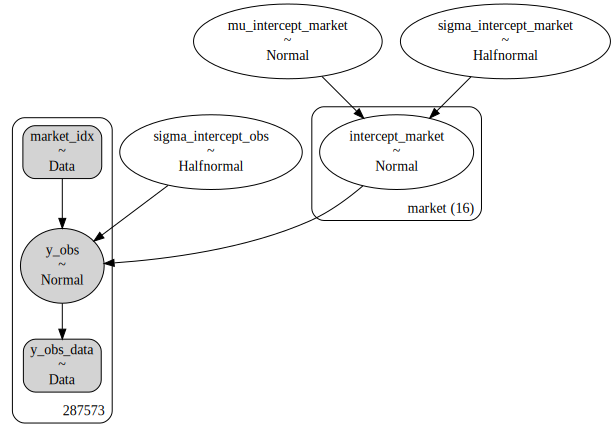

In [93]:
pm.model_to_graphviz(price_model)

In [94]:
with price_model:
    trace = pm.sample(draws=500, random_seed=42)

Output()

In [95]:
# Define unique markets and market indices
markets = np.sort(df_test.city.unique())
market_test_idx = pd.Categorical(df_test['city'], categories = markets).codes

with price_model:
    # Replace training indices/prices with test indices/prices
    pm.set_data({
        "market_idx": market_test_idx, # Ensure this matches the test rows
        "y_obs_data": df_test['Avg_Price'].values
    })

    # Generate predictions for the new data
    ppc_test = pm.sample_posterior_predictive(trace, var_names=["y_obs"])


# 1. Get true test values
y_true_test = df_test['Avg_Price'].values

# 2. Get predictions and reshape
# Shape will be (chains, draws, len(df_test))
y_pred_raw = ppc_test.posterior_predictive["y_obs"].values
chains, draws, obs = y_pred_raw.shape
y_pred_2d = y_pred_raw.reshape((chains * draws, obs))

# 3. Calculate the R2 score for Unseen Data
r2_test = az.r2_score(y_true_test, y_pred_2d)

print(f"Out-of-Sample Bayesian R2: {r2_test.r2:.3f}")

Output()

Out-of-Sample Bayesian R2: 0.335


## Model Validation

In [98]:
with pm.Model(coords = coords) as price_model_2:
  # Defining the indices
  market_idx = pm.Data("market_idx", market_idx)
  bedroom_count = pm.Data("bedroom_count", df_train['Bedrooms'].values)
  y_obs_data = pm.Data("y_obs_data", df_train['Avg_Price'].values)

  # =====================
  # Level 1: Market
  # =====================
  mu_intercept_market = pm.Normal("mu_intercept_market", mu = 80, sigma = 60)
  sigma_intercept_market = pm.HalfNormal("sigma_intercept_market", sigma = 30)

  intercept_market = pm.Normal("intercept_market", mu = mu_intercept_market, sigma = sigma_intercept_market, dims = "market")

  mu_slope_bedroom_market = pm.Normal("mu_slope_bedroom_market", mu = 50, sigma = 30)
  sigma_slope_bedroom_market = pm.HalfNormal("sigma_slope_bedroom_market", sigma = 30)
  slope_bedroom_market = pm.Normal("slope_bedroom_market", mu = mu_slope_bedroom_market, sigma = sigma_slope_bedroom_market, dims = 'market')

  # =====================
  # Level 2: Observation
  # =====================
  sigma_intercept_obs = pm.Exponential("sigma_intercept_obs", 1)

  y_obs = pm.Normal("y_obs", mu = intercept_market[market_idx] + slope_bedroom_market[market_idx]*bedroom_count, sigma = sigma_intercept_obs, observed = y_obs_data)

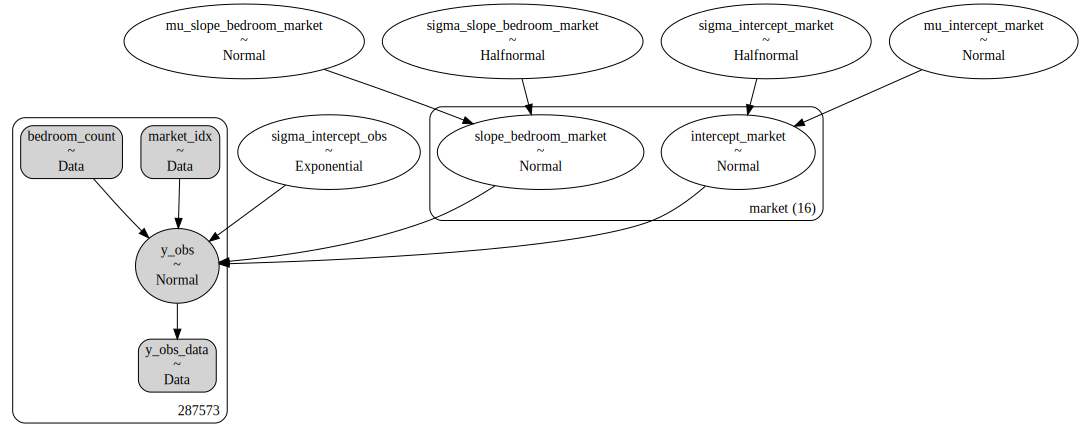

In [99]:
pm.model_to_graphviz(price_model_2)

In [ ]:
with price_model_2:
    trace = pm.sample(draws=500, random_seed=42)

Output()

In [ ]:
# Define unique markets and market indices
markets = np.sort(df_test.city.unique())
market_test_idx = pd.Categorical(df_test['city'], categories = markets).codes

with price_model:
    # Replace training indices/prices with test indices/prices
    pm.set_data({
        "market_idx": market_test_idx, # Ensure this matches the test rows
        "bedroom_count": df_test['Bedrooms'].values,
        "y_obs_data": df_test['Avg_Price'].values
    })

    # Generate predictions for the new data
    ppc_test = pm.sample_posterior_predictive(trace, var_names=["y_obs"])


# 1. Get true test values
y_true_test = df_test['Avg_Price'].values

# 2. Get predictions and reshape
# Shape will be (chains, draws, len(df_test))
y_pred_raw = ppc_test.posterior_predictive["y_obs"].values
chains, draws, obs = y_pred_raw.shape
y_pred_2d = y_pred_raw.reshape((chains * draws, obs))

# 3. Calculate the R2 score for Unseen Data
r2_test = az.r2_score(y_true_test, y_pred_2d)

print(f"Out-of-Sample Bayesian R2: {r2_test.r2:.3f}")